In [100]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
import joblib

Loading House Price Data Set

In [70]:
df=pd.read_csv("ahmedabad_house_price.csv")

In [71]:
df

,Location,BHK,Total_Area_Sqft,Condition,Furnishing,Floor_Level,Nearby_Amenities_Score,Price_Per_Sqft,Estimated_Price,Property_Age,Total_Floors,Has_Parking,Balcony_View,Year_Of_Sale
0,SG Highway,1,1459,New,Fully-Furnished,Ground,4,7260,10592340,12,14,1,Park,2022
1,Naranpura,3,1906,Resale,Unfurnished,2nd,8,4608,8783705,23,4,1,Road,2024
2,Satellite,1,751,Resale,Fully-Furnished,2nd,5,7298,5481008,3,3,0,Lake,2022
3,South Bopal,1,1034,Under Construction,Semi-Furnished,2nd,10,4097,4235858,15,16,0,Park,2025
4,Naranpura,3,2225,New,Unfurnished,3rd,9,5859,13036275,7,14,0,NaN,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,Gota,1,2462,Under Construction,Semi-Furnished,4th,6,4082,10050868,10,4,0,Road,2025
296,Maninagar,2,1993,New,Semi-Furnished,5th+,9,5166,10295838,18,13,0,Road,2022
297,Vastrapur,2,1313,New,Semi-Furnished,5th+,1,6212,8156093,13,11,1,Road,2025
298,South Bopal,2,2067,Resale,Semi-Furnished,3rd,6,4477,9253504,12,16,0,Park,2024


Now we are performing EDA on the data set

In [72]:
df.head()

,Location,BHK,Total_Area_Sqft,Condition,Furnishing,Floor_Level,Nearby_Amenities_Score,Price_Per_Sqft,Estimated_Price,Property_Age,Total_Floors,Has_Parking,Balcony_View,Year_Of_Sale
0,SG Highway,1,1459,New,Fully-Furnished,Ground,4,7260,10592340,12,14,1,Park,2022
1,Naranpura,3,1906,Resale,Unfurnished,2nd,8,4608,8783705,23,4,1,Road,2024
2,Satellite,1,751,Resale,Fully-Furnished,2nd,5,7298,5481008,3,3,0,Lake,2022
3,South Bopal,1,1034,Under Construction,Semi-Furnished,2nd,10,4097,4235858,15,16,0,Park,2025
4,Naranpura,3,2225,New,Unfurnished,3rd,9,5859,13036275,7,14,0,NaN,2024


In [73]:
df.tail()

,Location,BHK,Total_Area_Sqft,Condition,Furnishing,Floor_Level,Nearby_Amenities_Score,Price_Per_Sqft,Estimated_Price,Property_Age,Total_Floors,Has_Parking,Balcony_View,Year_Of_Sale
295,Gota,1,2462,Under Construction,Semi-Furnished,4th,6,4082,10050868,10,4,0,Road,2025
296,Maninagar,2,1993,New,Semi-Furnished,5th+,9,5166,10295838,18,13,0,Road,2022
297,Vastrapur,2,1313,New,Semi-Furnished,5th+,1,6212,8156093,13,11,1,Road,2025
298,South Bopal,2,2067,Resale,Semi-Furnished,3rd,6,4477,9253504,12,16,0,Park,2024
299,Chandkheda,3,2296,New,Unfurnished,3rd,5,3995,9172520,15,14,1,Lake,2025


In [74]:
df.shape

(300, 14)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Location                300 non-null    object
 1   BHK                     300 non-null    int64 
 2   Total_Area_Sqft         300 non-null    int64 
 3   Condition               300 non-null    object
 4   Furnishing              300 non-null    object
 5   Floor_Level             300 non-null    object
 6   Nearby_Amenities_Score  300 non-null    int64 
 7   Price_Per_Sqft          300 non-null    int64 
 8   Estimated_Price         300 non-null    int64 
 9   Property_Age            300 non-null    int64 
 10  Total_Floors            300 non-null    int64 
 11  Has_Parking             300 non-null    int64 
 12  Balcony_View            221 non-null    object
 13  Year_Of_Sale            300 non-null    int64 
dtypes: int64(9), object(5)
memory usage: 32.9+ KB


 Balcony_View null value handlng

In [76]:
df.isnull().sum()

Location                   0
BHK                        0
Total_Area_Sqft            0
Condition                  0
Furnishing                 0
Floor_Level                0
Nearby_Amenities_Score     0
Price_Per_Sqft             0
Estimated_Price            0
Property_Age               0
Total_Floors               0
Has_Parking                0
Balcony_View              79
Year_Of_Sale               0
dtype: int64

In [77]:
df.describe()

,BHK,Total_Area_Sqft,Nearby_Amenities_Score,Price_Per_Sqft,Estimated_Price,Property_Age,Total_Floors,Has_Parking,Year_Of_Sale
count,300.000000,300.000000,300.000000,300.000000,3.000000e+02,300.000000,300.000000,300.000000,300.000000
mean,2.390000,1471.096667,5.463333,5016.153333,7.314094e+06,14.730000,11.250000,0.536667,2023.113333
std,1.114469,615.708875,2.895387,1085.726570,3.405657e+06,9.407734,5.273855,0.499487,1.442483
min,1.000000,408.000000,1.000000,2898.000000,1.705297e+06,0.000000,3.000000,0.000000,2021.000000
25%,1.000000,971.500000,3.000000,4209.500000,4.478504e+06,6.000000,6.000000,0.000000,2022.000000
50%,2.000000,1443.000000,5.000000,4891.000000,6.995904e+06,15.000000,11.000000,1.000000,2023.000000
75%,3.000000,2003.250000,8.000000,5673.250000,9.540312e+06,23.000000,16.000000,1.000000,2024.000000
max,4.000000,2494.000000,10.000000,8168.000000,1.661137e+07,30.000000,20.000000,1.000000,2025.000000


In [78]:
#hadling mising catogrical values
df['Balcony_View'].value_counts()

Balcony_View
Road    78
Lake    72
Park    71
Name: count, dtype: int64

In [79]:
df['Balcony_View'].mode()[0]

'Road'

In [80]:
df['Balcony_View']=df['Balcony_View'].fillna(df['Balcony_View'].mode()[0])
df['Balcony_View'].value_counts()

Balcony_View
Road    157
Lake     72
Park     71
Name: count, dtype: int64

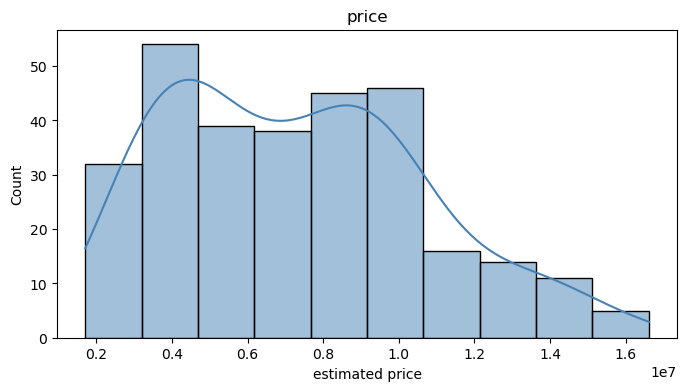

In [81]:
plt.figure(figsize=(8,4))
sns.histplot(df['Estimated_Price'], kde=True, color='steelblue')
plt.title('price')
plt.xlabel('estimated price')
plt.show()

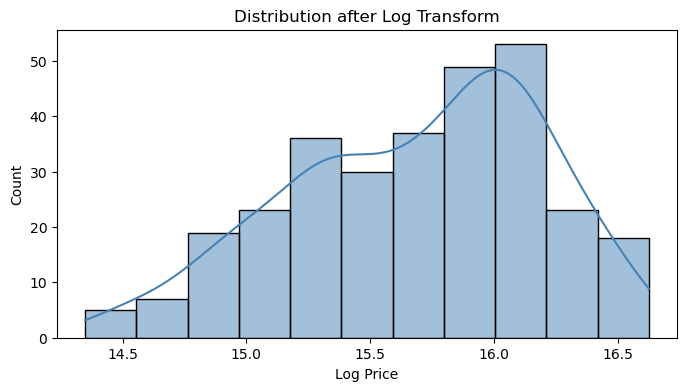

In [82]:
##creating new colum because estimate price to compress big number together so model can learn propely so we use "log_price" as new label
df['Log_Price'] = np.log(df['Estimated_Price'])

plt.figure(figsize=(8,4))
sns.histplot(df['Log_Price'], kde=True, color='steelblue')
plt.title('Distribution after Log Transform')
plt.xlabel('Log Price')
plt.show()

Text(0.5, 1.0, 'price vs location')

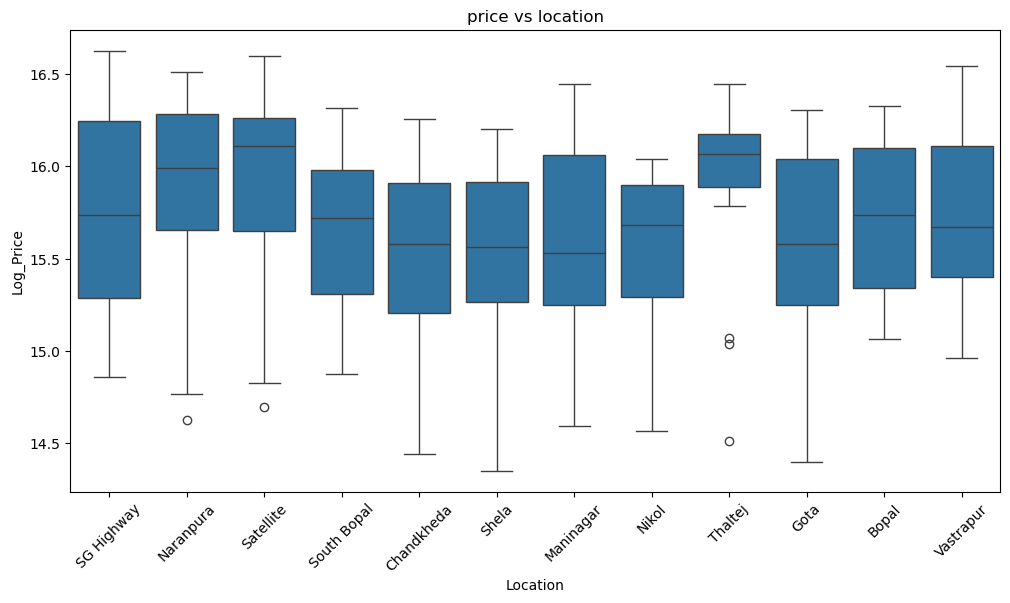

In [83]:
#making box plot so we can see which catogrical value most affects the price
#price vs location
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x="Location",y="Log_Price" )
plt.xticks(rotation=45)
plt.title("price vs location")

Text(0.5, 1.0, 'price vs Condition')

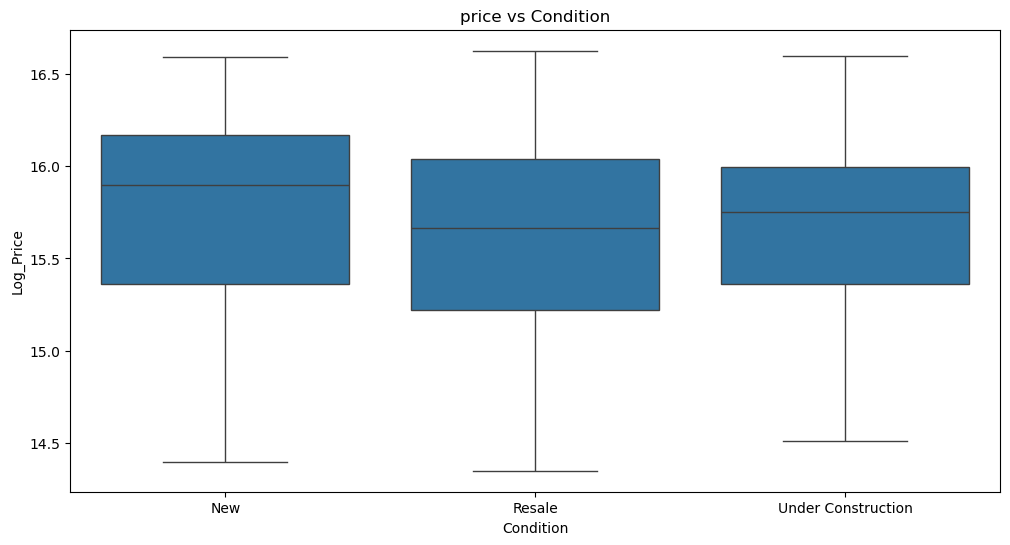

In [84]:
#price vs  condition
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x="Condition",y="Log_Price" )
##plt.xticks(rotation=90)
plt.title("price vs Condition")

Text(0.5, 1.0, 'price vs Furnishing')

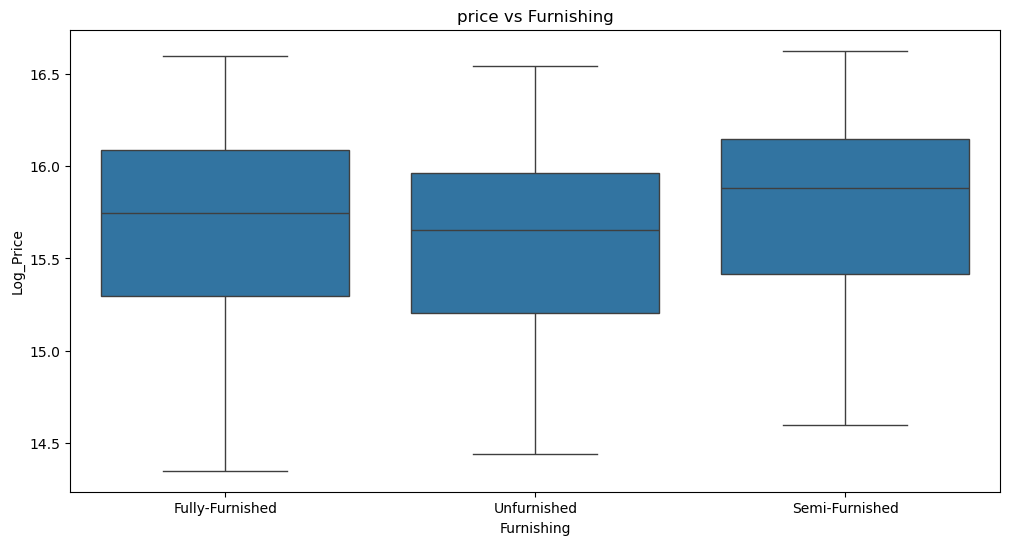

In [85]:
#price vs Furnishing
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x="Furnishing",y="Log_Price" )
##plt.xticks(rotation=90)
plt.title("price vs Furnishing")

locatin  most affects price and then furnishing and last condition is least affect the price

In [86]:
df.head()

,Location,BHK,Total_Area_Sqft,Condition,Furnishing,Floor_Level,Nearby_Amenities_Score,Price_Per_Sqft,Estimated_Price,Property_Age,Total_Floors,Has_Parking,Balcony_View,Year_Of_Sale,Log_Price
0,SG Highway,1,1459,New,Fully-Furnished,Ground,4,7260,10592340,12,14,1,Park,2022,16.175642
1,Naranpura,3,1906,Resale,Unfurnished,2nd,8,4608,8783705,23,4,1,Road,2024,15.988409
2,Satellite,1,751,Resale,Fully-Furnished,2nd,5,7298,5481008,3,3,0,Lake,2022,15.516800
3,South Bopal,1,1034,Under Construction,Semi-Furnished,2nd,10,4097,4235858,15,16,0,Park,2025,15.259096
4,Naranpura,3,2225,New,Unfurnished,3rd,9,5859,13036275,7,14,0,Road,2024,16.383246


In [87]:
#droping price per squre feet and estimate price it is data leakege
df.drop("Price_Per_Sqft", axis=1, inplace=True, errors='ignore')
df.drop("Estimated_Price", axis=1, inplace=True, errors='ignore')

In [88]:
df.columns

Index(['Location', 'BHK', 'Total_Area_Sqft', 'Condition', 'Furnishing',
       'Floor_Level', 'Nearby_Amenities_Score', 'Property_Age', 'Total_Floors',
       'Has_Parking', 'Balcony_View', 'Year_Of_Sale', 'Log_Price'],
      dtype='object')

In [89]:
df.head()

,Location,BHK,Total_Area_Sqft,Condition,Furnishing,Floor_Level,Nearby_Amenities_Score,Property_Age,Total_Floors,Has_Parking,Balcony_View,Year_Of_Sale,Log_Price
0,SG Highway,1,1459,New,Fully-Furnished,Ground,4,12,14,1,Park,2022,16.175642
1,Naranpura,3,1906,Resale,Unfurnished,2nd,8,23,4,1,Road,2024,15.988409
2,Satellite,1,751,Resale,Fully-Furnished,2nd,5,3,3,0,Lake,2022,15.516800
3,South Bopal,1,1034,Under Construction,Semi-Furnished,2nd,10,15,16,0,Park,2025,15.259096
4,Naranpura,3,2225,New,Unfurnished,3rd,9,7,14,0,Road,2024,16.383246


In [90]:
df['Floor_Level'].unique()

array(['Ground', '2nd', '3rd', '1st', '4th', '5th+'], dtype=object)

In [91]:
#we use ordinal encoding on floot level because it has structure is in order and manually map nubers..
floor_mapping={'Ground':0,'1st':1,'2nd':2,'3rd':3,'4th':4,'5th+':5}
df['Floor_Level']=df['Floor_Level'].map(floor_mapping)
print(df['Floor_Level'].value_counts())

Floor_Level
3    57
2    54
0    50
5    49
1    45
4    45
Name: count, dtype: int64


In [92]:
#now encoding the condition,furnishing,balcony view
df=pd.get_dummies(df,columns=['Condition','Furnishing','Balcony_View'],drop_first=True)

In [93]:
X=df.drop('Log_Price',axis=1)
y=df['Log_Price']

In [94]:
#traing and testing creating

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("train size:",X_train.shape)
print("test size:",X_test.shape)

train size: (240, 15)
test size: (60, 15)


In [95]:
#encoding most importanT feture location AND We use target encoding for this AND this advanced encoding
temp=X_train.copy()
temp['Log_Price']=y_train

#mean of per location
loc_mean=temp.groupby('Location')['Log_Price'].mean()
X_train['Location']=X_train['Location'].map(loc_mean)
X_test['Location']=X_test['Location'].map(loc_mean)
X_test["Location"] = X_test["Location"].fillna(loc_mean.mean())

now train difernt models

In [96]:
#Randomforest regression

rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
#for checking accrucey of model using R2 and Root mean squre error
rf_r2=r2_score(y_test,rf_pred)#we don't have to covert log price to estimated price because it use it checks between actual vs predicted
rf_mae=mean_absolute_error(np.exp(y_test),np.exp(rf_pred))
rf_cv=cross_val_score(rf,X_train,y_train,cv=5,scoring='r2').mean()#using cross validation mwthod on traning data
print(f"RandomForest-->R2:{rf_r2:.4f}")
print(f"CROSS VALIDATION-->R²:{rf_cv:.4f}")
print(f"MEAN Absolute Eror-->mae:{rf_mae:,.0f}")

RandomForest-->R2:0.9513
CROSS VALIDATION-->R²:0.9342
MEAN Absolute Eror-->mae:653,439


In [101]:
#xgboost regrssion 
xgb=XGBRegressor(n_estimators=100,random_state=42)
xgb.fit(X_train,y_train)
xgb_pred=xgb.predict(X_test)
xgb_r2=r2_score(y_test,xgb_pred)
xgb_mae=mean_absolute_error(np.exp(y_test),np.exp(xgb_pred))
xgb_cv=cross_val_score(xgb,X_train,y_train,cv=5,scoring='r2').mean()
print(f"XGBOOST-->R2:{xgb_r2:.4f}")
print(f"CROSS VALIDATION-->R²:{xgb_cv:.4f}")
print(f"MEAN Absolute Eror-->mae:{xgb_mae:,.0f}")
print("selected model!")

XGBOOST-->R2:0.9543
CROSS VALIDATION-->R²:0.9422
MEAN Absolute Eror-->mae:607,756
selected model!


Now we select xgboost model now we infernce the model so we can save Using a trained model to make predictions on new data

In [103]:
joblib.dump(xgb,'house_price_model.pkl')
print("model saved!")

model saved


In [106]:
joblib.dump(loc_mean,'location_encoding.pkl')
print("location enccoding saved!")

location enccoding saved!


In [108]:
X_train.columns.tolist()

['Location',
 'BHK',
 'Total_Area_Sqft',
 'Floor_Level',
 'Nearby_Amenities_Score',
 'Property_Age',
 'Total_Floors',
 'Has_Parking',
 'Year_Of_Sale',
 'Condition_Resale',
 'Condition_Under Construction',
 'Furnishing_Semi-Furnished',
 'Furnishing_Unfurnished',
 'Balcony_View_Park',
 'Balcony_View_Road']

In [109]:
joblib.dump(X_train.columns.tolist(),'model_columns.pkl')
print("columns saved")

columns saved
